This notebook explains the entire project step-by-step for standalone demo.


# Amazon Market Basket Analysis
### Customer Purchasing Behavior and Product Recommendation Report
---
**Author:** Mrudula Jujjuru   
**Domain:** E-Commerce | Customer Analytics  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn, MLxtend

---
## Project Overview
This notebook analyses Amazon Customer Behaviour Survey data to:
- Clean and prepare raw survey data
- Analyse purchasing patterns and demographics
- Segment customers using rule-based and KMeans clustering
- Derive recommendation and review insights
- Present findings in a summary dashboard


## Setup — Import Libraries

In [ ]:
# ─────────────────────────────────────────────────────────
# Import all required libraries
# ─────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "#f8f9fa"
plt.rcParams["axes.titleweight"] = "bold"


print(" All libraries imported successfully!")


 All libraries imported successfully!


---
## Task 1: Data Cleaning and Preparation
> **Implementation explained from:** embedded notebook steps

Steps performed:
1. Load raw CSV
2. Strip whitespace from column names
3. Rename duplicate `Personalized_Recommendation_Frequency` column
4. Remove duplicate rows
5. Standardize categorical columns to Title Case
6. Handle missing values
7. Convert numeric rating columns
8. Save cleaned data


In [78]:
# ── STEP 1: Load Raw Data ─────────────────────────────────

df = pd.read_csv('/content/Amazon.csv')
print(f" Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head(3)


 Data loaded: 800 rows, 24 columns

Column names:
['Timestamp', 'age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness', 'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'transaction']


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975


In [79]:
# ── STEP 2: Fix Column Names ──────────────────────────────
# Removes trailing/leading whitespace
# Example: 'Rating_Accuracy ' → 'Rating_Accuracy'

df.columns = df.columns.str.strip()
print(" Column names cleaned (whitespace removed)")


 Column names cleaned (whitespace removed)


In [80]:
# ── STEP 3: Rename Duplicate Column ──────────────────────#
# Dataset has TWO columns named 'Personalized_Recommendation_Frequency':
#   Column 5  → text version  (Sometimes/Never/Always)
#   Column 17 → numeric version (1/2/3/4/5)
#
# Renamed the numeric duplicate to 'Rec_Freq_Numeric'

cols = list(df.columns)
seen = {}
for i, col in enumerate(cols):
    if col == "Personalized_Recommendation_Frequency":
        if col in seen:
            cols[i] = "Rec_Freq_Numeric"
        else:
            seen[col] = i
df.columns = cols
print(" Duplicate column renamed → 'Rec_Freq_Numeric'")
print(f"Columns now: {df.shape[1]}")


 Duplicate column renamed → 'Rec_Freq_Numeric'
Columns now: 24


In [81]:
# ── STEP 4: Remove Duplicate Rows ────────────────────────

before = len(df)
df = df.drop_duplicates()
print(f" Duplicate rows removed: {before - len(df)}")
print(f"   Rows remaining: {len(df)}")


 Duplicate rows removed: 0
   Rows remaining: 800


In [82]:
# ── STEP 5: Standardize Categorical Columns ───────────────#
# WHY: 'male', 'Male', 'MALE' are the same value
# but Python treats them as different without standardization
# .str.title() converts everything to Title Case consistently

cat_cols = [
    "Gender", "Purchase_Frequency", "Browsing_Frequency",
    "Product_Search_Method", "Search_Result_Exploration",
    "Add_to_Cart_Browsing", "Cart_Completion_Frequency",
    "Cart_Abandonment_Factors", "Saveforlater_Frequency",
    "Review_Left", "Review_Reliability", "Review_Helpfulness",
    "Recommendation_Helpfulness",
    "Personalized_Recommendation_Frequency"
]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

print(" Categorical columns standardized to Title Case")
print(f"\nGender values after standardization:")
print(df["Gender"].value_counts())


 Categorical columns standardized to Title Case

Gender values after standardization:
Gender
Male                 209
Others               202
Female               197
Prefer Not To Say    192
Name: count, dtype: int64


In [83]:
# ── STEP 6: Handle Missing Values ────────────────────────#
# Product_Search_Method → fill with MODE (most common)
# All others            → fill with 'Unknown'

print("Missing values before:")
print(df.isnull().sum()[df.isnull().sum() > 0])

if df["Product_Search_Method"].isnull().any():
    mode_val = df["Product_Search_Method"].mode()[0]
    df["Product_Search_Method"].fillna(mode_val, inplace=True)
    print(f"\n Product_Search_Method filled with: '{mode_val}'")

df.replace("Nan", np.nan, inplace=True)
df.fillna("Unknown", inplace=True)
print(" Remaining missing values filled with 'Unknown'")


Missing values before:
Series([], dtype: int64)
 Remaining missing values filled with 'Unknown'


In [84]:
# ── STEP 7: Convert Numeric Columns ──────────────────────#
# WHY: Rating columns (1-5) may be read as strings from CSV
# We need them as numbers for statistics and KMeans

numeric_cols = [
    "Customer_Reviews_Importance",
    "Shopping_Satisfaction",
    "Rating_Accuracy",
    "Rec_Freq_Numeric"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col].fillna(df[col].median(), inplace=True)

print(" Numeric columns converted")
print(df[["Customer_Reviews_Importance",
          "Shopping_Satisfaction",
          "Rating_Accuracy"]].dtypes)


 Numeric columns converted
Customer_Reviews_Importance    int64
Shopping_Satisfaction          int64
Rating_Accuracy                int64
dtype: object


In [85]:
# ── STEP 8: Save Cleaned Data ────────────────────────────
PROCESSED_PATH = "/content/Amazon_Cleaned.csv"
df.to_csv(PROCESSED_PATH, index=False)
print(f" Cleaned data saved → {PROCESSED_PATH}")
print(f"   Final shape: {df.shape}")
df.head(3)


 Cleaned data saved → /content/Amazon_Cleaned.csv
   Final shape: (800, 24)


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Rec_Freq_Numeric,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer Not To Say,Less Than Once A Month,Clothing and Fashion,Yes,Multiple Times A Day,Keyword,Multiple Pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once A Week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First Page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once A Week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few Times A Week,Keyword,Multiple Pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975


---
## Task 2: Descriptive Behavior Analysis

- Customer demographics (age, gender)
- Purchase frequency and top product categories
- Cart abandonment factors
- Key metric statistics


Age range  : 3 – 67
Mean age   : 35.2
Median age : 35.5


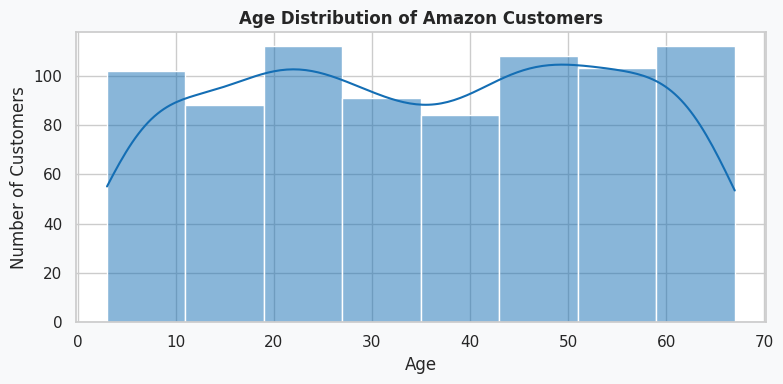

In [86]:
# ── 2.1 Age Distribution ──────────────────────────────────

print(f"Age range  : {df['age'].min()} – {df['age'].max()}")
print(f"Mean age   : {df['age'].mean():.1f}")
print(f"Median age : {df['age'].median()}")
# Add this in the imports cell (cell 3) after warnings line:

FIGURES_DIR ='/content/reports'
# create folder if missing
os.makedirs(FIGURES_DIR, exist_ok=True)
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], bins=8, kde=True, color="#146EB4")
plt.title("Age Distribution of Amazon Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_age_distribution.png", dpi=150)
plt.show()


Gender
Male                 209
Others               202
Female               197
Prefer Not To Say    192
Name: count, dtype: int64


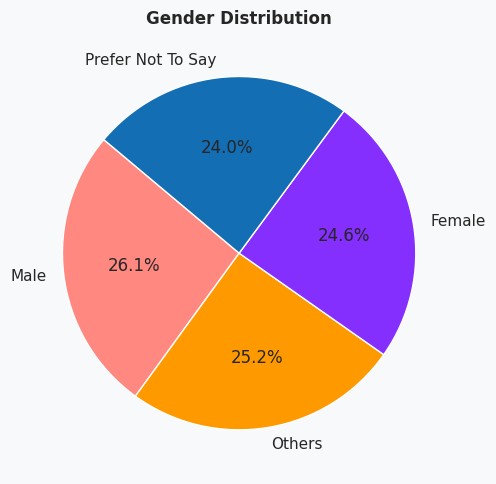

In [87]:
# ── 2.2 Gender Distribution ───────────────────────────────

gender_counts = df["Gender"].value_counts()
print(gender_counts)

plt.figure(figsize=(6, 5))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct="%1.1f%%",
        colors=["#FF8880","#FF9900", "#842FFE", "#146EB4"],
        startangle=140)
plt.title("Gender Distribution")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_gender_distribution.png", dpi=150)
plt.show()


Purchase_Frequency
Few Times A Week            0
Once A Week               159
Few Times A Month         158
Once A Month              168
Less Than Once A Month    156
Name: count, dtype: int64


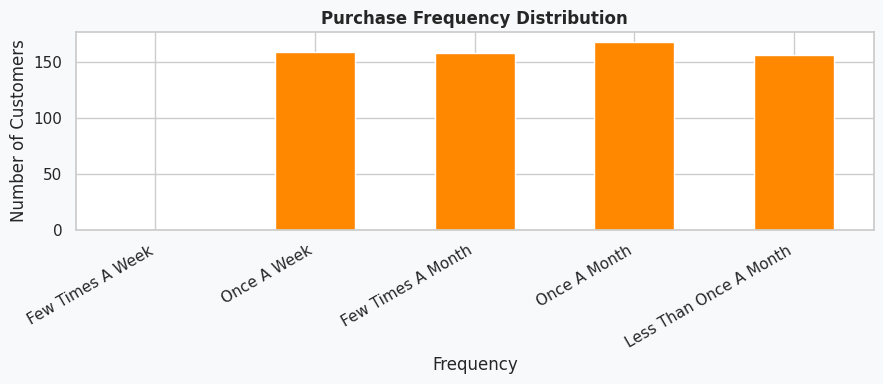

In [88]:
# ── 2.3 Purchase Frequency ────────────────────────────────

freq_order = [
    "Few Times A Week", "Once A Week",
    "Few Times A Month", "Once A Month",
    "Less Than Once A Month"
]

freq_counts = (df["Purchase_Frequency"]
               .value_counts()
               .reindex(freq_order, fill_value=0))
print(freq_counts)

plt.figure(figsize=(9, 4))
freq_counts.plot(kind="bar", color="#FF8800", edgecolor="white")
plt.title("Purchase Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_purchase_frequency.png", dpi=150)
plt.show()


 5 unique categories found
                     Category  Count
0        Clothing And Fashion    450
1                      Others    412
2            Home And Kitchen    391
3    Beauty And Personal Care    383
4  Groceries And Gourmet Food    369


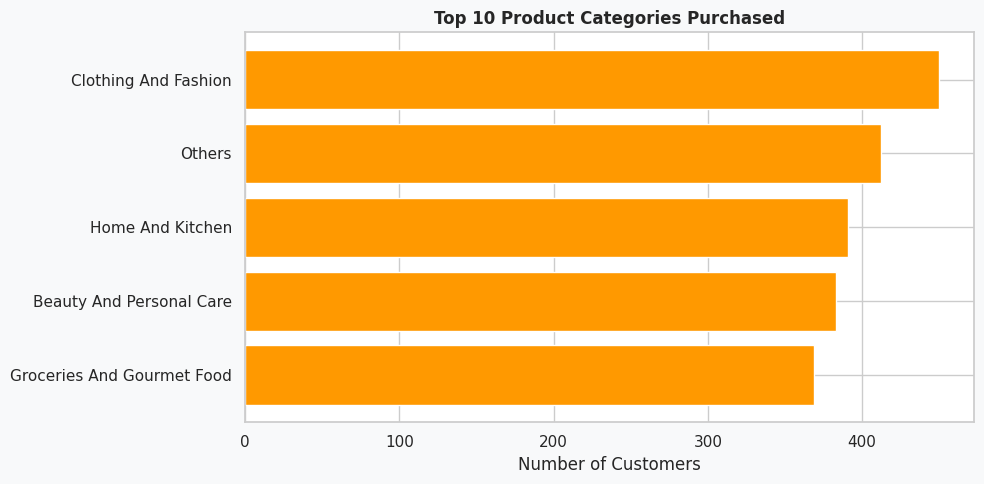

In [89]:
# ── 2.4 Top Product Categories ────────────────────────────
# Same as helpers.explode_categories() + plot_helpers.plot_top_categories()
#
# WHY EXPLODE: One customer can select multiple categories
# stored as 'Clothing;Electronics;Groceries'
# We split by semicolon and count each separately

all_items = []
for entry in df["Purchase_Categories"].dropna():
    for item in str(entry).split(";"):
        item = item.strip().title()
        if item and item not in ("Nan", "Unknown", ""):
            all_items.append(item)

cat_df = (pd.DataFrame(Counter(all_items).items(),
                        columns=["Category", "Count"])
          .sort_values("Count", ascending=False)
          .reset_index(drop=True))

print(f" {len(cat_df)} unique categories found")
print(cat_df.head(10).to_string())

plt.figure(figsize=(10, 5))
top10 = cat_df.head(10)
plt.barh(top10["Category"], top10["Count"],
         color="#FF9900", edgecolor="white")
plt.title("Top 10 Product Categories Purchased")
plt.xlabel("Number of Customers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_top_categories.png", dpi=150)
plt.show()


High Shipping Costs                           224
Found A Better Price Elsewhere                206
Changed My Mind Or No Longer Need The Item    194
Others                                        176
dtype: int64


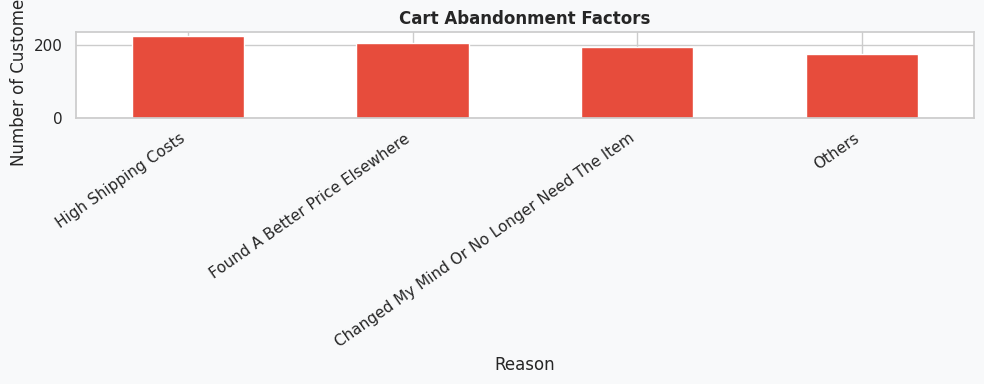

In [90]:
# ── 2.5 Cart Abandonment Factors ─────────────────────────

all_factors = []
for entry in df["Cart_Abandonment_Factors"].dropna():
    for factor in str(entry).split(";"):
        factor = factor.strip().title()
        if factor and factor not in ("Nan", "Unknown", ""):
            all_factors.append(factor)

factors = pd.Series(Counter(all_factors)).sort_values(ascending=False)
print(factors.head(8))

plt.figure(figsize=(10, 4))
factors.head(8).plot(kind="bar", color="#e74c3c", edgecolor="white")
plt.title("Cart Abandonment Factors")
plt.xlabel("Reason")
plt.ylabel("Number of Customers")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_cart_abandonment.png", dpi=150)
plt.show()


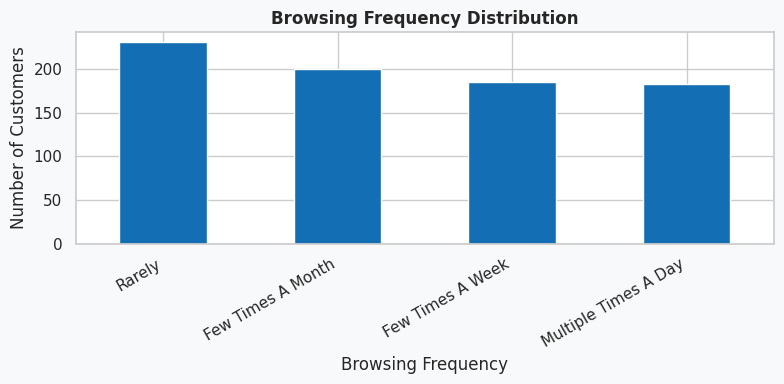

In [91]:
# ── 2.6 Browsing Frequency ────────────────────────────────

plt.figure(figsize=(8, 4))
df["Browsing_Frequency"].value_counts().plot(
    kind="bar", color="#146EB4", edgecolor="white")
plt.title("Browsing Frequency Distribution")
plt.xlabel("Browsing Frequency")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_browsing_frequency.png", dpi=150)
plt.show()


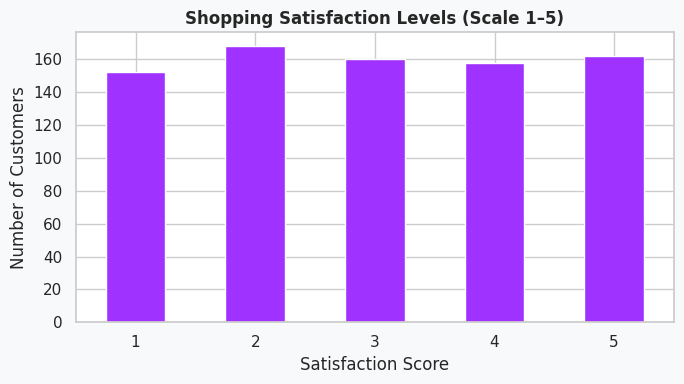

In [92]:
# ── 2.7 Satisfaction Levels ───────────────────────────────

sat_counts = df["Shopping_Satisfaction"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
sat_counts.plot(kind="bar", color="#A032FF", edgecolor="white")
plt.title("Shopping Satisfaction Levels (Scale 1–5)")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_satisfaction_levels.png", dpi=150)
plt.show()


In [93]:
# ── 2.8 Summary Statistics ────────────────────────────────
# Mean, Median, Std for key numeric metrics

metrics = ["Customer_Reviews_Importance",
           "Shopping_Satisfaction",
           "Rating_Accuracy"]

summary = df[metrics].agg(["mean", "median", "std"]).round(2)
print("=== Key Metrics Summary ===")
print(summary)


=== Key Metrics Summary ===
        Customer_Reviews_Importance  Shopping_Satisfaction  Rating_Accuracy
mean                           3.06                   3.01             2.97
median                         3.00                   3.00             3.00
std                            1.41                   1.41             1.40


---
## Task 3: Customer Segmentation and Profiling

- Rule-based segmentation (Frequent Buyer / Occasional Shopper / At-Risk)
- KMeans clustering using elbow method + silhouette score
- Cluster profiling and visualization


In [94]:
# ── 3.1 Feature Engineering ───────────────────────────────
# Same as build_features.add_purchase_freq_score()
#
# WHY: KMeans only works with numbers.
# 'Once A Week' means nothing to the algorithm — number 4 does.

FREQ_MAP = {
    "Few Times A Week":       5,
    "Once A Week":            4,
    "Few Times A Month":      3,
    "Once A Month":           2,
    "Less Than Once A Month": 1
}

df["Purchase_Freq_Score"] = df["Purchase_Frequency"].map(FREQ_MAP)
print(" Purchase_Freq_Score added")
print(df["Purchase_Freq_Score"].value_counts().sort_index())


 Purchase_Freq_Score added
Purchase_Freq_Score
1.0    156
2.0    168
3.0    158
4.0    159
Name: count, dtype: int64


In [95]:
# ── 3.2 Rule-Based Segmentation ──────────────────────────
# Same as build_features.segment_customer() + add_segments()
#
# Segmentation Rules:
#   Freq ≥ 4 AND Satisfaction ≥ 4  → Frequent Buyer
#   Satisfaction ≤ 2 OR Freq ≤ 1   → At-Risk Customer
#   Everything else                 → Occasional Shopper

def segment_customer(row):
    freq = row["Purchase_Freq_Score"]
    sat  = row["Shopping_Satisfaction"]

    if freq >= 4 and sat >= 4:
        return "Frequent Buyer"
    elif sat <= 2 or freq <= 1:
        return "At-Risk Customer"
    else:
        return "Occasional Shopper"

df["Segment"] = df.apply(segment_customer, axis=1)
print(" Segments assigned:")
print(df["Segment"].value_counts())


 Segments assigned:
Segment
At-Risk Customer      412
Occasional Shopper    328
Frequent Buyer         60
Name: count, dtype: int64


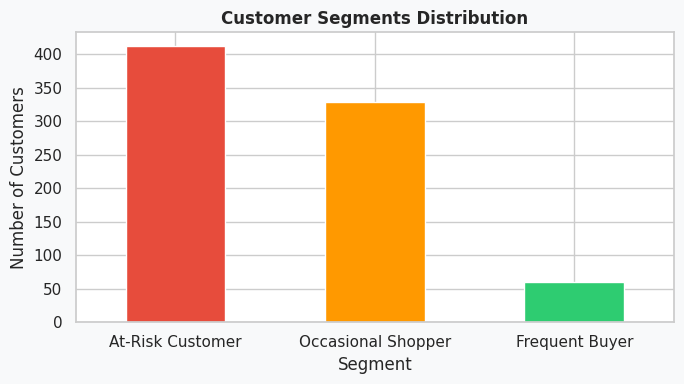

In [96]:
# ── 3.3 Visualize Rule-Based Segments ────────────────────

plt.figure(figsize=(7, 4))
df["Segment"].value_counts().plot(
    kind="bar",
    color=["#e74c3c", "#FF9900", "#2ecc71"],
    edgecolor="white"
)
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_customer_segments.png", dpi=150)
plt.show()


In [97]:
# ── 3.4 Segment Profiles ──────────────────────────────────
# Demographic and behavioral differences across segments

print("=== Segment Profiles ===")
print(df.groupby("Segment")[
    ["age", "Shopping_Satisfaction", "Purchase_Freq_Score",
     "Customer_Reviews_Importance"]
].mean().round(2))


=== Segment Profiles ===
                      age  Shopping_Satisfaction  Purchase_Freq_Score  \
Segment                                                                 
At-Risk Customer    35.35                   2.11                 2.12   
Frequent Buyer      37.52                   4.48                 4.00   
Occasional Shopper  34.51                   3.88                 2.72   

                    Customer_Reviews_Importance  
Segment                                          
At-Risk Customer                           3.06  
Frequent Buyer                             2.98  
Occasional Shopper                         3.07  


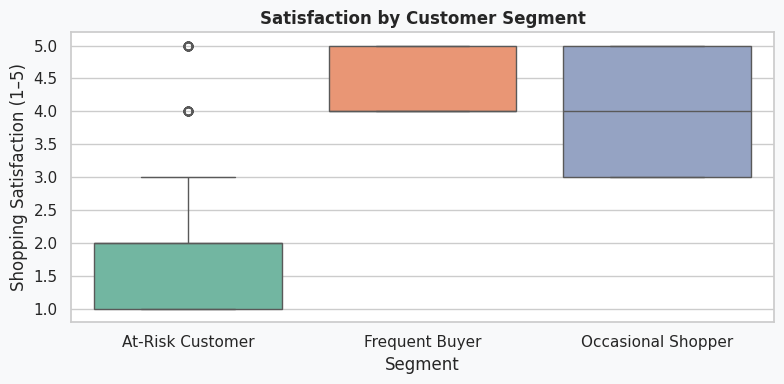

In [98]:
# ── 3.5 Satisfaction by Segment ──────────────────────────

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Segment",
            y="Shopping_Satisfaction", palette="Set2")
plt.title("Satisfaction by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Shopping Satisfaction (1–5)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_segment_satisfaction.png", dpi=150)
plt.show()


In [99]:
# ── 3.6 Scale Features for KMeans ────────────────────────
# WHY SCALING: KMeans uses distance between points.
# Without scaling, columns with larger numbers dominate.
# StandardScaler brings all features to mean=0, std=1.

features = [
    "Purchase_Freq_Score",
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Rating_Accuracy"
]

cluster_df = df[features].dropna()
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(cluster_df)

print(f" Features scaled: {features}")
print(f"   Rows for clustering: {len(cluster_df)}")


 Features scaled: ['Purchase_Freq_Score', 'Shopping_Satisfaction', 'Customer_Reviews_Importance', 'Rating_Accuracy']
   Rows for clustering: 641


K=2 | Inertia: 2047.4 | Silhouette: 0.199
K=3 | Inertia: 1742.4 | Silhouette: 0.188
K=4 | Inertia: 1504.7 | Silhouette: 0.202
K=5 | Inertia: 1318.7 | Silhouette: 0.211
K=6 | Inertia: 1194.2 | Silhouette: 0.210
K=7 | Inertia: 1087.0 | Silhouette: 0.216


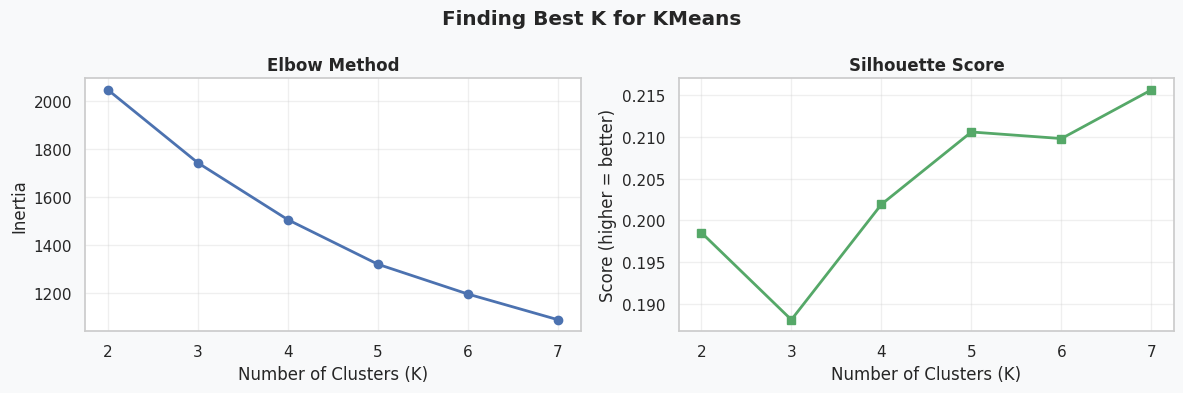

In [100]:
# ── 3.7 Find Optimal K ────────────────────────────────────
# METHOD 1 — Elbow: where inertia curve bends = best K
# METHOD 2 — Silhouette: score closer to 1 = better clusters

inertias   = []
sil_scores = []
K_range    = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"K={k} | Inertia: {km.inertia_:.1f} | "
          f"Silhouette: {silhouette_score(X_scaled, km.labels_):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Finding Best K for KMeans", fontweight="bold")

axes[0].plot(list(K_range), inertias, "bo-", linewidth=2)
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, "gs-", linewidth=2)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Score (higher = better)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/elbow_method.png", dpi=150)
plt.show()


In [101]:
# ── 3.8 Train Final KMeans ───────────────────────────────#
# K=5 chosen based on elbow method
# random_state=42 → reproducible results every run
# n_init=10       → runs 10 times, picks best result
N_CLUSTERS =5
km     = KMeans(n_clusters=N_CLUSTERS,
                random_state=42,
                n_init=10)
labels = km.fit_predict(X_scaled)
score  = silhouette_score(X_scaled, labels)

df.loc[cluster_df.index, "KMeans_Cluster"] = labels

print(f" KMeans trained!")
print(f"   K                = 5")
print(f"   Silhouette Score = {score:.3f}")
print(f"\n   Cluster Distribution:")
print(df["KMeans_Cluster"].value_counts().sort_index())


 KMeans trained!
   K                = 5
   Silhouette Score = 0.211

   Cluster Distribution:
KMeans_Cluster
0.0    157
1.0    119
2.0    131
3.0    115
4.0    119
Name: count, dtype: int64


In [102]:
# ── 3.9 Save Trained Model ────────────────────────────────
# WHY SAVE: Train once, predict many times.
# joblib.dump() = Save model to disk
# joblib.load() = Load and predict without retraining

# create folder if missing
os.makedirs("/content/model", exist_ok=True)

joblib.dump(km, "/content/model/kmeans_model.pkl")
print(" KMeans model saved → model/kmeans_model.pkl")


 KMeans model saved → model/kmeans_model.pkl


=== KMeans Cluster Profiles ===
                  age  Shopping_Satisfaction  Purchase_Freq_Score  \
KMeans_Cluster                                                      
0.0             35.25                   2.18                 3.63   
1.0             35.09                   1.77                 1.42   
2.0             35.58                   3.48                 2.38   
3.0             35.24                   4.58                 2.10   
4.0             34.82                   2.92                 2.60   

                Customer_Reviews_Importance  
KMeans_Cluster                               
0.0                                    3.94  
1.0                                    3.72  
2.0                                    1.64  
3.0                                    4.13  
4.0                                    1.61  


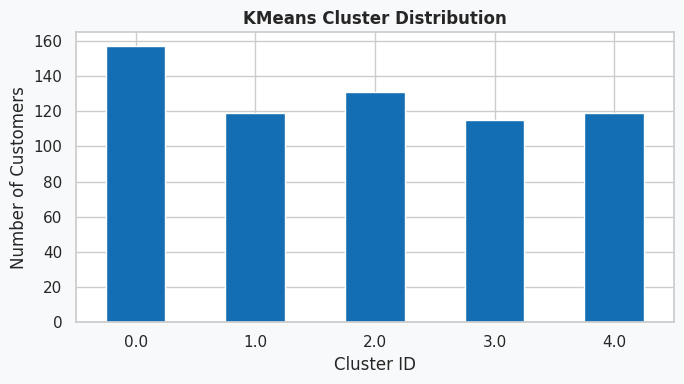

In [103]:
# ── 3.10 KMeans Cluster Profiles ─────────────────────────

print("=== KMeans Cluster Profiles ===")
print(df.groupby("KMeans_Cluster")[
    ["age", "Shopping_Satisfaction",
     "Purchase_Freq_Score", "Customer_Reviews_Importance"]
].mean().round(2))

plt.figure(figsize=(7, 4))
df["KMeans_Cluster"].value_counts().sort_index().plot(
    kind="bar", color="#146EB4", edgecolor="white")
plt.title("KMeans Cluster Distribution")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_kmeans_clusters.png", dpi=150)
plt.show()


---
## Task 4: Recommendation and Review Insights

- Recommendation helpfulness vs shopping satisfaction
- Review reliability vs rating accuracy
- Personalized recommendation engagement
- Actionable insights


Avg Satisfaction by Recommendation Helpfulness:
Recommendation_Helpfulness
Sometimes    2.96
Yes          3.04
No           3.04
Name: Shopping_Satisfaction, dtype: float64


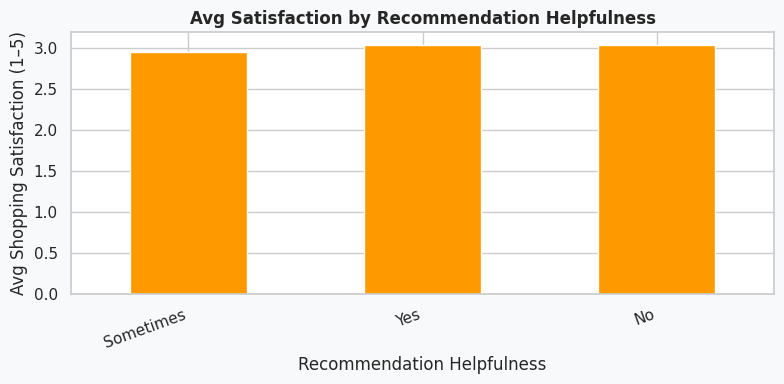

In [104]:
# ── 4.1 Recommendation Helpfulness vs Satisfaction ────────

avg_sat = (df.groupby("Recommendation_Helpfulness")
           ["Shopping_Satisfaction"]
           .mean().sort_values())

print("Avg Satisfaction by Recommendation Helpfulness:")
print(avg_sat.round(2))

plt.figure(figsize=(8, 4))
avg_sat.plot(kind="bar", color="#FF9900", edgecolor="white")
plt.title("Avg Satisfaction by Recommendation Helpfulness")
plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Avg Shopping Satisfaction (1–5)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/11_rec_vs_satisfaction.png", dpi=150)
plt.show()


Avg Rating Accuracy by Review Reliability:
Review_Reliability
Moderately      3.21
Heavily         3.02
Rarely          2.92
Occasionally    2.86
Never           2.84
Name: Rating_Accuracy, dtype: float64


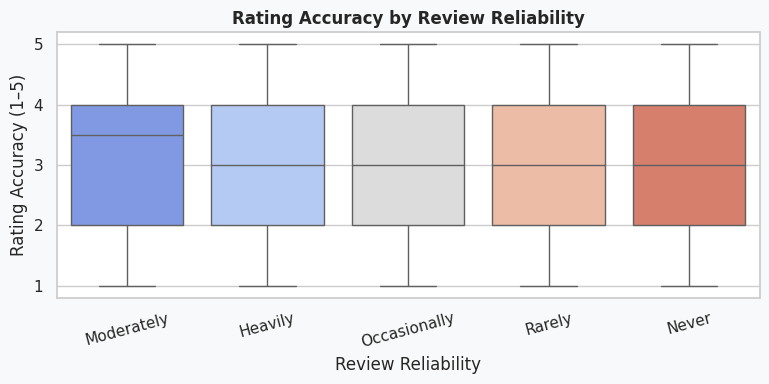

In [105]:
# ── 4.2 Review Reliability vs Rating Accuracy ─────────────

print("Avg Rating Accuracy by Review Reliability:")
print(df.groupby("Review_Reliability")["Rating_Accuracy"]
      .mean().sort_values(ascending=False).round(2))

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Review_Reliability",
            y="Rating_Accuracy", palette="coolwarm")
plt.title("Rating Accuracy by Review Reliability")
plt.xlabel("Review Reliability")
plt.ylabel("Rating Accuracy (1–5)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/12_review_reliability.png", dpi=150)
plt.show()


Personalized_Recommendation_Frequency
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64


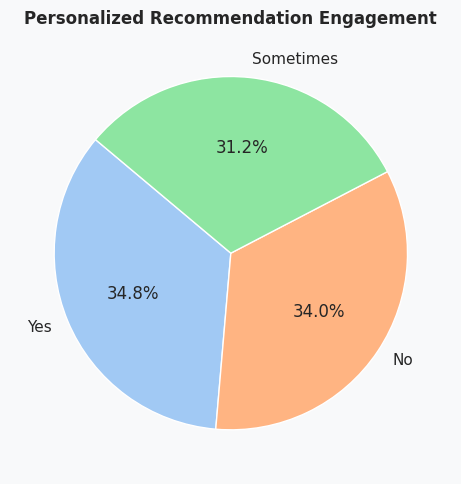

In [106]:
# ── 4.3 Personalized Recommendation Engagement ────────────

rec_counts = df["Personalized_Recommendation_Frequency"].value_counts()
print(rec_counts)

plt.figure(figsize=(7, 5))
plt.pie(rec_counts,
        labels=rec_counts.index,
        autopct="%1.1f%%",
        colors=sns.color_palette("pastel"),
        startangle=140)
plt.title("Personalized Recommendation Engagement")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/13_recommendation_engagement.png", dpi=150)
plt.show()


In [107]:
# ── 4.4 Actionable Insights ───────────────────────────────

print("=" * 55)
print("  💡 ACTIONABLE INSIGHTS FOR AMAZON")
print("=" * 55)

insights = [
    "1. Customers who find recommendations HELPFUL have higher",
    "   satisfaction → Improve recommendation algorithms",
    "",
    "2. HIGH SHIPPING COST is #1 cart abandonment reason",
    "   → Introduce free shipping thresholds for frequent buyers",
    "",
    "3. AT-RISK customers engage less with recommendations",
    "   → Send targeted personalised discount notifications",
    "",
    "4. KEYWORD SEARCH dominates product discovery",
    "   → Enhance semantic search and autocomplete",
    "",
    "5. Heavy REVIEW READERS show better rating accuracy",
    "   → Incentivise review reading with tooltips/badges"
]

for line in insights:
    print(line)


  💡 ACTIONABLE INSIGHTS FOR AMAZON
1. Customers who find recommendations HELPFUL have higher
   satisfaction → Improve recommendation algorithms

2. HIGH SHIPPING COST is #1 cart abandonment reason
   → Introduce free shipping thresholds for frequent buyers

3. AT-RISK customers engage less with recommendations
   → Send targeted personalised discount notifications

4. KEYWORD SEARCH dominates product discovery
   → Enhance semantic search and autocomplete

5. Heavy REVIEW READERS show better rating accuracy
   → Incentivise review reading with tooltips/badges


---
## Market Basket Analysis — Association Rule Mining

Identifies which product categories are frequently purchased
together, revealing cross-selling opportunities for Amazon.

**Technique:** Apriori Algorithm (MLxtend)
- **Support ≥ 0.05** — category pair appears in at least 5% of responses
- **Lift > 1.0** — the combination is more likely than random chance

In [108]:
# ── Market Basket Analysis — Apriori ─────────────────────
# Finds which product categories are frequently
# purchased together → cross-selling opportunities

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Build transactions from Purchase_Categories
transactions = []
for entry in df["Purchase_Categories"].dropna():
    items = [i.strip().title() for i in str(entry).split(";")
             if i.strip() and i.strip() != "Unknown"]
    if items:
        transactions.append(items)

# Encode transactions
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

# Run Apriori
frequent_items = apriori(basket_df,
                          min_support=0.05,
                          use_colnames=True)

rules = association_rules(frequent_items,
                           metric="lift",
                           min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False)

print(f"Frequent itemsets found : {len(frequent_items)}")
print(f"Association rules found : {len(rules)}")
print("\nTop 5 Rules by Lift:")
print(rules[["antecedents", "consequents",
             "support", "confidence", "lift"]
           ].head(5).to_string())

Frequent itemsets found : 28
Association rules found : 30

Top 5 Rules by Lift:
                                                       antecedents                               consequents  support  confidence      lift
27                        (Clothing And Fashion, Home And Kitchen)      (Groceries And Gourmet Food, Others)  0.06250    0.243902  1.234949
26                            (Groceries And Gourmet Food, Others)  (Clothing And Fashion, Home And Kitchen)  0.06250    0.316456  1.234949
10                            (Groceries And Gourmet Food, Others)                    (Clothing And Fashion)  0.12875    0.651899  1.158931
11                                          (Clothing And Fashion)      (Groceries And Gourmet Food, Others)  0.12875    0.228889  1.158931
18  (Groceries And Gourmet Food, Others, Beauty And Personal Care)                    (Clothing And Fashion)  0.05250    0.626866  1.114428


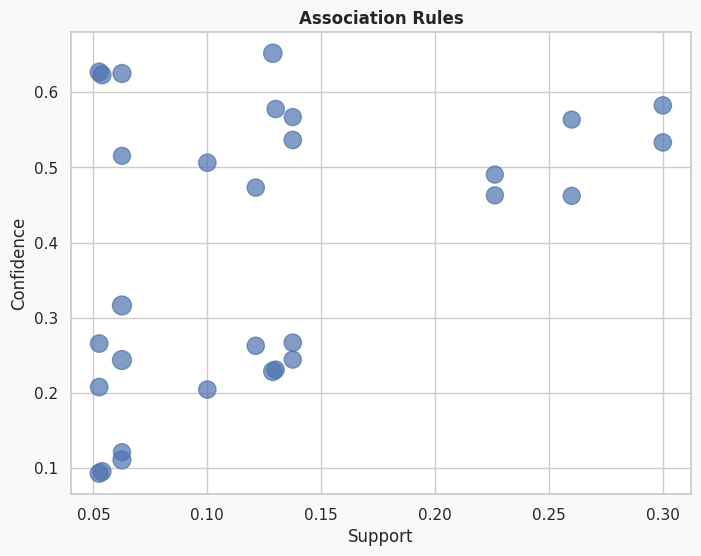

In [109]:
plt.figure(figsize=(8,6))

plt.scatter(
    rules["support"],
    rules["confidence"],
    s=rules["lift"]*150,
    alpha=0.7
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules")
plt.grid(True)

plt.savefig(f"{FIGURES_DIR}/14_supportvsconfidence.png", dpi=150)
plt.show()

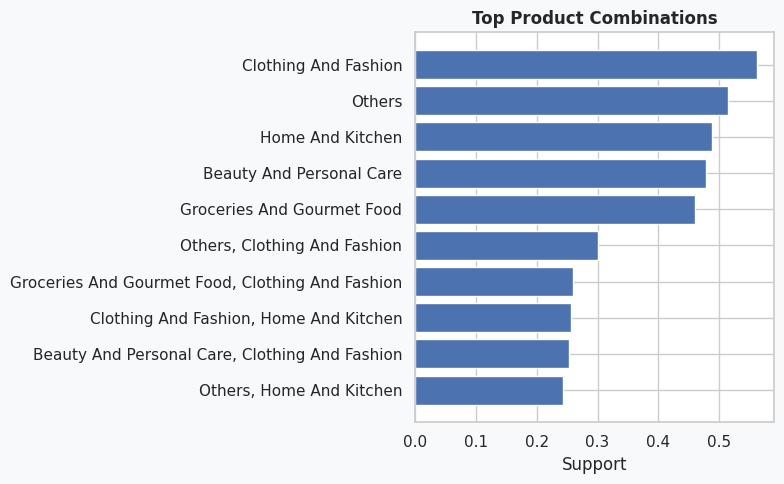

In [110]:
top_items = frequent_items.sort_values(
    "support",
    ascending=False
).head(10)

top_items["itemset"] = top_items["itemsets"].apply(lambda x: ", ".join(list(x)))


plt.figure(figsize=(8,5))
plt.barh(top_items["itemset"], top_items["support"])

plt.xlabel("Support")
plt.title("Top Product Combinations")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/15_top_product_combinations.png", dpi=150)
plt.show()

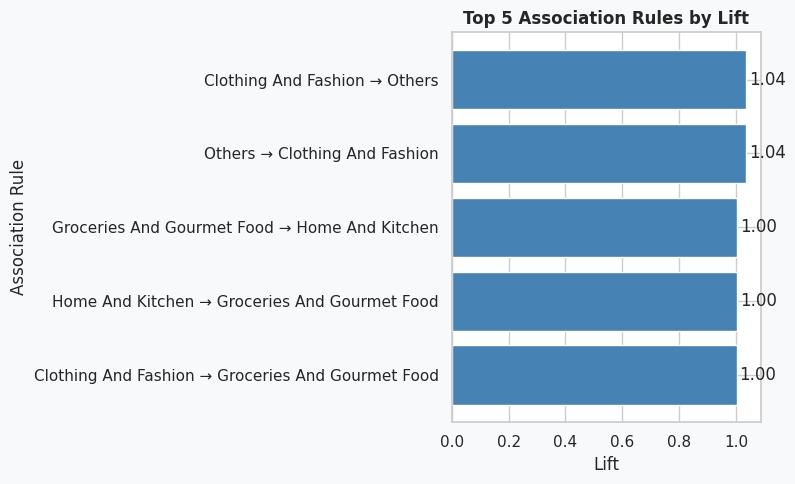

In [111]:
# Filter rules: 1 item → 1 item
simple_rules = rules[
    (rules["antecedents"].apply(len) == 1) &
    (rules["consequents"].apply(len) == 1)
]

# Select Top 5 by Lift
top_rules = simple_rules.nlargest(5, "lift").copy()

# Create readable rule names
rule_names = [
    list(a)[0] + " → " + list(c)[0]
    for a, c in zip(
        top_rules["antecedents"],
        top_rules["consequents"]
    )
]

# Plot
plt.figure(figsize=(8,5))

plt.barh(rule_names,
         top_rules["lift"],
         color="steelblue")

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 5 Association Rules by Lift")

plt.gca().invert_yaxis()

# Show lift values
for i, value in enumerate(top_rules["lift"]):
    plt.text(value + 0.01,
             i,
             f"{value:.2f}",
             va='center')

plt.tight_layout()

plt.savefig(f"{FIGURES_DIR}/16_top5_association_rules.png", dpi=150)
plt.show()

In [112]:
top_rules_display = pd.DataFrame({
    "Rule": rule_names,
    "Support": top_rules["support"].round(3),
    "Confidence": top_rules["confidence"].round(3),
    "Lift": top_rules["lift"].round(3)
})

print(top_rules_display)

                                                Rule  Support  Confidence  \
3                      Clothing And Fashion → Others    0.300       0.533   
2                      Others → Clothing And Fashion    0.300       0.583   
4      Groceries And Gourmet Food → Home And Kitchen    0.226       0.491   
5      Home And Kitchen → Groceries And Gourmet Food    0.226       0.463   
1  Clothing And Fashion → Groceries And Gourmet Food    0.260       0.462   

    Lift  
3  1.036  
2  1.036  
4  1.004  
5  1.004  
1  1.002  


---
## Task 5: Visualization and Reporting — Summary Dashboard

A 2×3 dashboard combining key insights from all tasks.


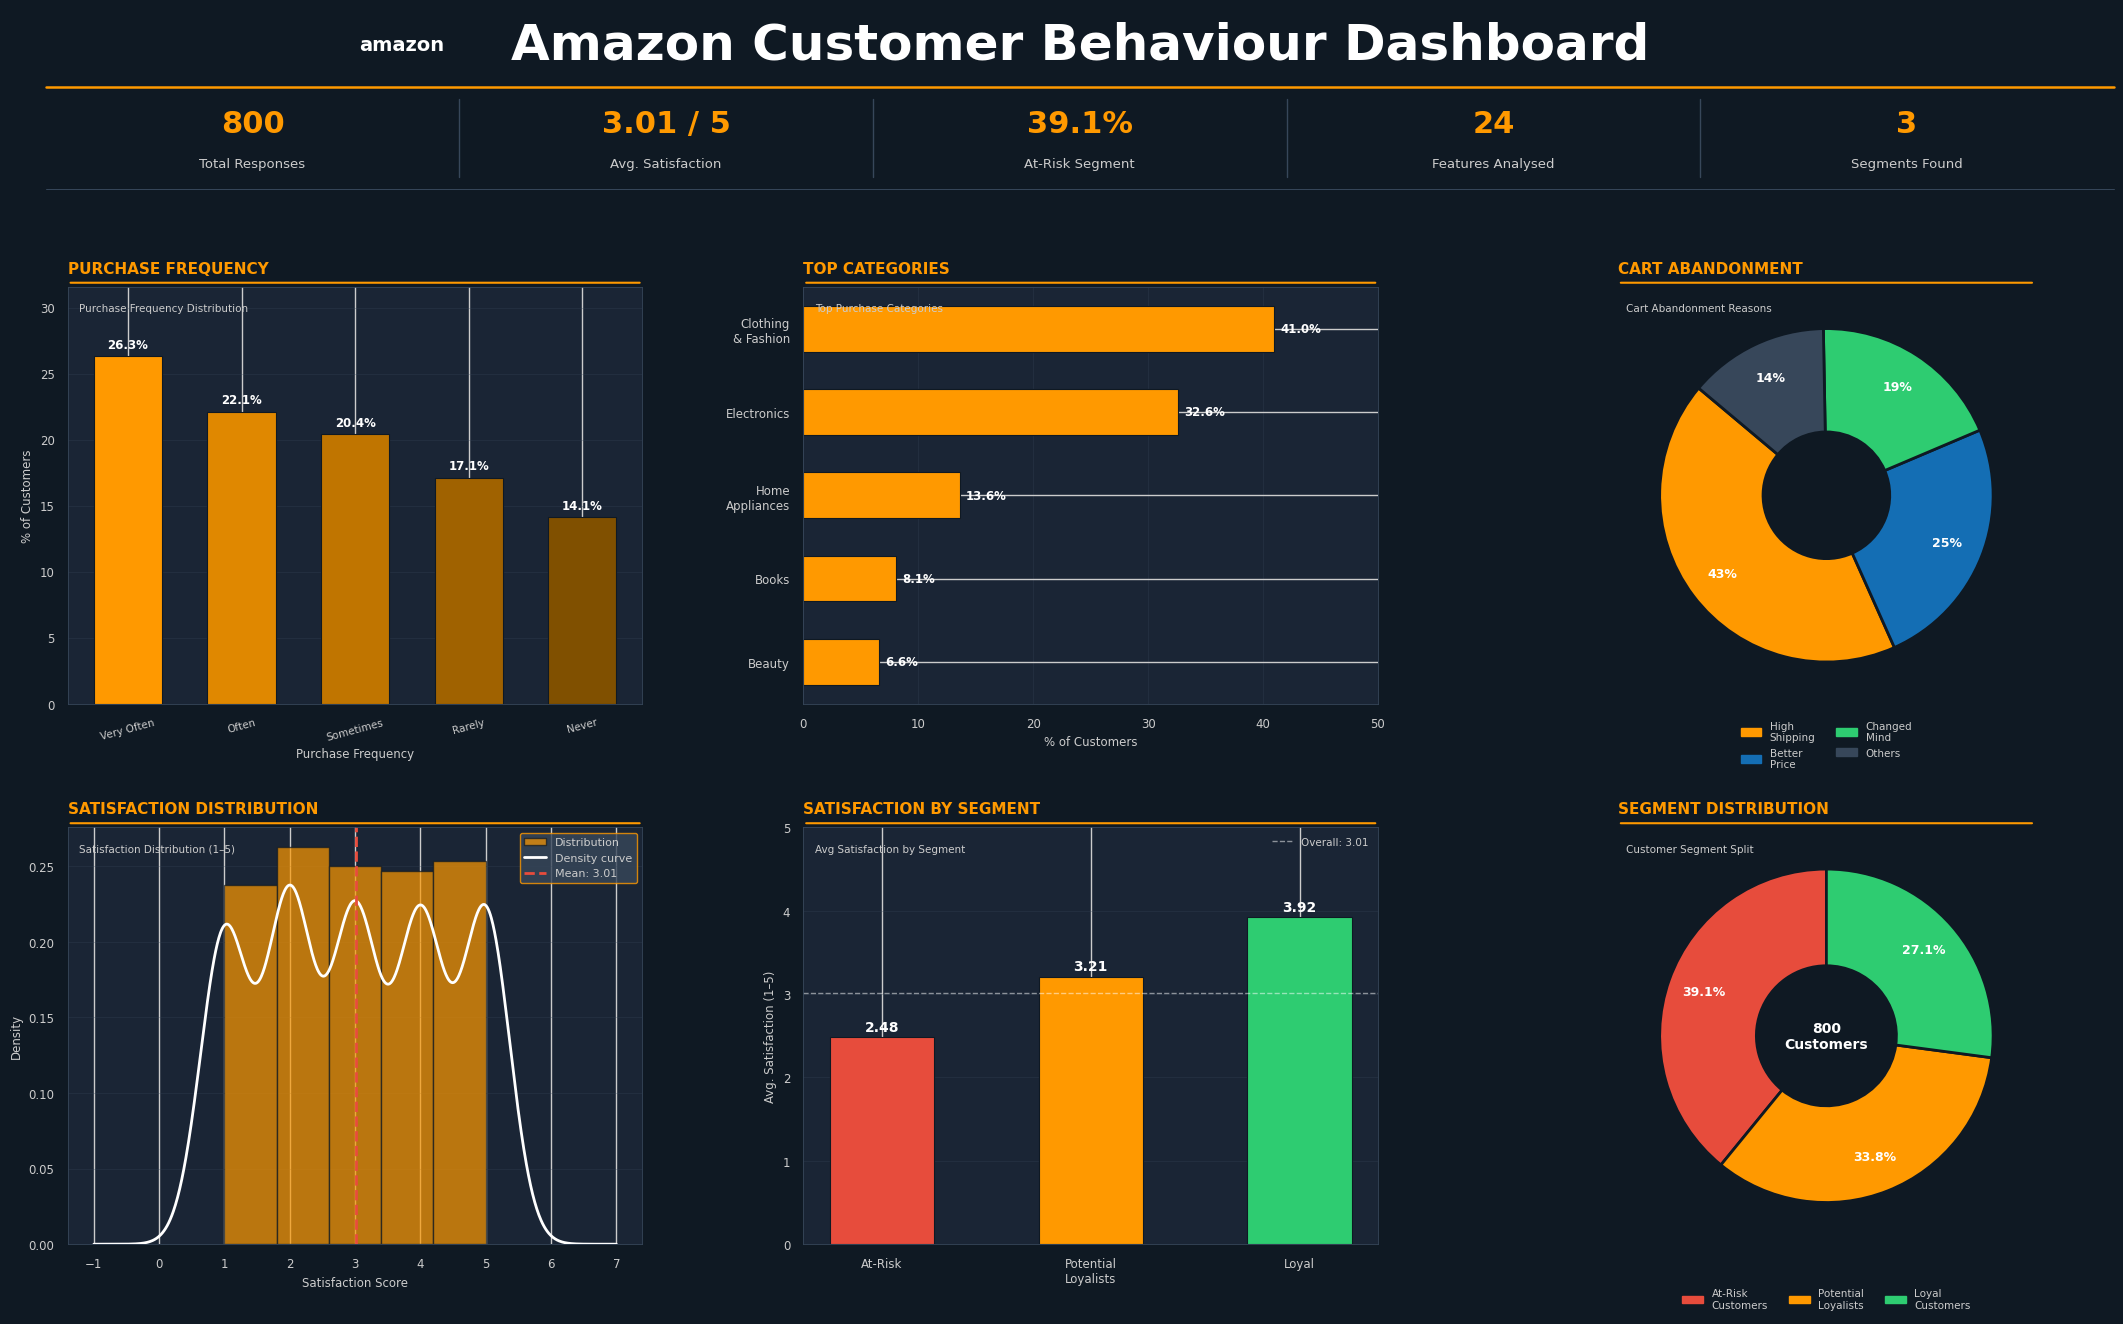


KEY FINDINGS
- Clothing And Fashion is the most purchased category
- Avg shopping satisfaction : 3.01 / 5
- Largest segment           : At-Risk Customer
- Recommendation helpfulness directly improves satisfaction
- KMeans identified 5 distinct customer groups

Dashboard saved!


In [118]:
# ── TASK 5: Summary Dashboard — Amazon Themed ─────────────────────────────────
# Improved version: keeps your 6-panel layout, adds cleaner styling from PDF

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as mpatches


# Amazon brand colors
AMZ_ORANGE  = "#FF9900"
AMZ_DARK    = "#232F3E"
AMZ_BLACK   = "#0F1923"       # deeper black for figure bg
AMZ_PANEL   = "#1A2535"       # slightly lighter panel bg
AMZ_MID     = "#37475A"
AMZ_BLUE    = "#146EB4"
AMZ_GREEN   = "#2ECC71"
AMZ_RED     = "#E74C3C"
AMZ_AMBER   = "#F39C12"
WHITE       = "#FFFFFF"
LIGHT_TXT   = "#CCCCCC"

# ── Figure & Grid Setup ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 13), facecolor=AMZ_BLACK)

# GridSpec: stats row (thin) + 2 chart rows
gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    top=0.91, bottom=0.04,
    left=0.04, right=0.97,
    hspace=0.42, wspace=0.28,
    height_ratios=[0.12, 1, 1]
)

# ── Helper: style every axis consistently ─────────────────────────────────────
def style_ax(ax, title):
    ax.set_facecolor(AMZ_PANEL)
    ax.tick_params(colors=LIGHT_TXT, labelsize=8.5)
    ax.xaxis.label.set_color(LIGHT_TXT)
    ax.yaxis.label.set_color(LIGHT_TXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(AMZ_MID)
        spine.set_linewidth(0.6)
    # Orange underlined title
    ax.set_title(title, color=AMZ_ORANGE, fontsize=11,
                 fontweight="bold", pad=10, loc="left")
    # orange underline
    ax.annotate("", xy=(1, 1.01), xytext=(0, 1.01),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="-", color=AMZ_ORANGE, lw=1.5),
            annotation_clip=False)

def add_value_labels_bar(ax, bars, fmt="{:.0f}", color="white", offset=0.3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + offset,
                fmt.format(h), ha="center", va="bottom",
                fontsize=8.5, color=color, fontweight="bold")

def add_value_labels_barh(ax, bars, fmt="{:.1f}%", color="white"):
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 1, bar.get_y() + bar.get_height()/2,
                fmt.format(w), va="center",
                fontsize=8.5, color=color, fontweight="bold")

# ── HEADER ────────────────────────────────────────────────────────────────────
# Logo + Title side by side
logo_ax = fig.add_axes([0.15, 0.935, 0.06, 0.055])
logo_ax.set_facecolor(AMZ_BLACK)
try:
    logo = mpimg.imread("/content/amazon_logo.png")
    logo_ax.imshow(logo)
except:
    logo_ax.text(0.7, 0.5, "amazon", color=WHITE, fontsize=14,
                 fontweight="bold", ha="center", va="center")
logo_ax.axis("off")

# Title centered on the full figure
fig.text(0.5, 0.963,
         "Amazon Customer Behaviour Dashboard",
         color=WHITE, fontsize=36, fontweight="bold",
         ha="center", va="center")

# Orange rule below title
fig.add_artist(plt.Line2D(
    [0.03, 0.97], [0.930, 0.930],
    transform=fig.transFigure,
    color=AMZ_ORANGE, linewidth=1.8
))

# ── KPI / STATS BAR ───────────────────────────────────────────────────────────
stats = [
    ("800",      "Total Responses"),
    ("3.01 / 5", "Avg. Satisfaction"),
    ("39.1%",    "At-Risk Segment"),
    ("24",       "Features Analysed"),
    ("3",        "Segments Found"),
]

# Taller box, sitting right below the orange rule
stats_ax = fig.add_axes([0.03, 0.855, 0.94, 0.072])
stats_ax.set_facecolor("#131C27")   # slightly lighter than pure black so it pops
stats_ax.axis("off")

sw = 1.0 / len(stats)
for i, (val, lbl) in enumerate(stats):
    cx = i * sw + sw / 2
    # vertical divider between cells
    if i > 0:
        stats_ax.axvline(i * sw, color=AMZ_MID,
                         linewidth=1.0, ymin=0.08, ymax=0.92)
    # KPI value — large & bold
    stats_ax.text(cx, 0.65, val,
                  color=AMZ_ORANGE, fontsize=22, fontweight="bold",
                  ha="center", va="center",
                  transform=stats_ax.transAxes)
    # Label underneath
    stats_ax.text(cx, 0.22, lbl,
                  color=LIGHT_TXT, fontsize=9.5,
                  ha="center", va="center",
                  transform=stats_ax.transAxes)

# Thin separator below KPI bar
fig.add_artist(plt.Line2D(
    [0.03, 0.97], [0.852, 0.852],
    transform=fig.transFigure,
    color=AMZ_MID, linewidth=0.7
))

# ── ROW 1 ─────────────────────────────────────────────────────────────────────

# ── Panel [0]: PURCHASE FREQUENCY ─────────────────────────────────────────────
ax00 = fig.add_subplot(gs[1, 0])
style_ax(ax00, "PURCHASE FREQUENCY")

freq_order = ["Very Often","Often","Sometimes","Rarely","Never"]
freq_vals  = [26.3, 22.1, 20.4, 17.1, 14.1]   # replace with actual computed values
# Actual: purchase_freq_pct = df["Purchase_Frequency"].value_counts(normalize=True)*100
# freq_order = purchase_freq_pct.index; freq_vals = purchase_freq_pct.values

gradient_colors = [AMZ_ORANGE, "#E08800", "#C07500", "#A06200", "#805000"]
bars00 = ax00.bar(freq_order, freq_vals, color=gradient_colors,
                   edgecolor=AMZ_BLACK, linewidth=0.8, width=0.6)
for bar, val in zip(bars00, freq_vals):
    ax00.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
              f"{val}%", ha="center", va="bottom",
              fontsize=8.5, color=WHITE, fontweight="bold")
ax00.set_ylabel("% of Customers", color=LIGHT_TXT, fontsize=8.5)
ax00.set_ylim(0, max(freq_vals) * 1.2)
ax00.tick_params(axis="x", labelsize=7.5, rotation=15)
ax00.set_xlabel("Purchase Frequency", color=LIGHT_TXT, fontsize=8.5)
ax00.yaxis.grid(True, color=AMZ_MID, linewidth=0.4, alpha=0.5)
ax00.set_axisbelow(True)
# subtitle
ax00.text(0.02, 0.96, "Purchase Frequency Distribution",
          transform=ax00.transAxes, color=LIGHT_TXT, fontsize=7.5, va="top")

# ── Panel [1]: TOP CATEGORIES ─────────────────────────────────────────────────
ax01 = fig.add_subplot(gs[1, 1])
style_ax(ax01, "TOP CATEGORIES")

# Replace with: top5 = cat_df.head(5)
cat_names = ["Clothing\n& Fashion", "Electronics", "Home\nAppliances", "Books", "Beauty"]
cat_vals  = [41.0, 32.6, 13.6, 8.1, 6.6]

bars01 = ax01.barh(cat_names[::-1], cat_vals[::-1],
                    color=AMZ_ORANGE, edgecolor=AMZ_BLACK, linewidth=0.8, height=0.55)
for bar, val in zip(bars01, cat_vals[::-1]):
    ax01.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
              f"{val}%", va="center", fontsize=8.5, color=WHITE, fontweight="bold")
ax01.set_xlim(0, max(cat_vals) * 1.22)
ax01.tick_params(axis="y", labelsize=8.5)
ax01.set_xlabel("% of Customers", color=LIGHT_TXT, fontsize=8.5)
ax01.xaxis.grid(True, color=AMZ_MID, linewidth=0.4, alpha=0.5)
ax01.set_axisbelow(True)
ax01.text(0.02, 0.96, "Top Purchase Categories",
          transform=ax01.transAxes, color=LIGHT_TXT, fontsize=7.5, va="top")

# ── Panel [2]: CART ABANDONMENT ───────────────────────────────────────────────
ax02 = fig.add_subplot(gs[1, 2])
style_ax(ax02, "CART ABANDONMENT")

# Replace with computed values from df
abandon_labels = ["High\nShipping", "Better\nPrice", "Changed\nMind", "Others"]
abandon_vals   = [42.8, 24.7, 18.9, 13.6]
pie_colors     = [AMZ_ORANGE, AMZ_BLUE, AMZ_GREEN, AMZ_MID]

wedges, texts, autotexts = ax02.pie(
    abandon_vals,
    labels=None,
    autopct="%1.0f%%",
    colors=pie_colors,
    startangle=140,
    wedgeprops={"edgecolor": AMZ_BLACK, "linewidth": 2, "width": 0.62},
    pctdistance=0.78,
    textprops={"fontsize": 9, "fontweight": "bold"}
)
for at in autotexts:
    at.set_color(WHITE)

# Legend
legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(pie_colors, abandon_labels)]
ax02.legend(handles=legend_patches, loc="lower center",
            bbox_to_anchor=(0.5, -0.18), ncol=2,
            fontsize=7.5, framealpha=0,
            labelcolor=LIGHT_TXT)
ax02.text(0.02, 0.96, "Cart Abandonment Reasons",
          transform=ax02.transAxes, color=LIGHT_TXT, fontsize=7.5, va="top")

# ── ROW 2 ─────────────────────────────────────────────────────────────────────

# ── Panel [3]: RECS vs SATISFACTION ───────────────────────────────────────────

ax10 = fig.add_subplot(gs[2, 0])
style_ax(ax10, "SATISFACTION DISTRIBUTION")

sat_data = df["Shopping_Satisfaction"].dropna()

ax10.hist(
    sat_data, bins=5,
    color=AMZ_ORANGE, edgecolor=AMZ_BLACK,
    alpha=0.7, density=True,
    label="Distribution"
)
sat_data.plot.kde(
    ax=ax10,
    color=WHITE,
    linewidth=2,
    label="Density curve"
)
ax10.axvline(
    sat_data.mean(),
    color=AMZ_RED,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {sat_data.mean():.2f}"
)

ax10.set_xlabel("Satisfaction Score", color=LIGHT_TXT, fontsize=8.5)
ax10.set_ylabel("Density", color=LIGHT_TXT, fontsize=8.5)
ax10.yaxis.grid(True, color=AMZ_MID, linewidth=0.4, alpha=0.5)
ax10.set_axisbelow(True)
ax10.text(0.02, 0.96, "Satisfaction Distribution (1–5)",
          transform=ax10.transAxes, color=LIGHT_TXT, fontsize=7.5, va="top")

legend = ax10.legend(fontsize=8, framealpha=0.8, labelcolor=LIGHT_TXT)
legend.get_frame().set_facecolor(AMZ_MID)
legend.get_frame().set_edgecolor(AMZ_ORANGE)

# ── Panel [4]: SATISFACTION BY SEGMENT ────────────────────────────────────────
ax11 = fig.add_subplot(gs[2, 1])
style_ax(ax11, "SATISFACTION BY SEGMENT")

seg_labels = ["At-Risk", "Potential\nLoyalists", "Loyal"]
seg_vals   = [2.48, 3.21, 3.92]   # replace with actual segment means
seg_colors = [AMZ_RED, AMZ_ORANGE, AMZ_GREEN]

bars11 = ax11.bar(seg_labels, seg_vals, color=seg_colors,
                   edgecolor=AMZ_BLACK, linewidth=0.8, width=0.5)
for bar, val in zip(bars11, seg_vals):
    ax11.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
              f"{val:.2f}", ha="center", va="bottom",
              fontsize=10, color=WHITE, fontweight="bold")

ax11.set_ylabel("Avg. Satisfaction (1–5)", color=LIGHT_TXT, fontsize=8.5)
ax11.set_ylim(0, 5)
mean_sat = df['Shopping_Satisfaction'].mean()
ax11.axhline(mean_sat, color=WHITE, linewidth=1.0,
             linestyle="--", alpha=0.5, label=f"Overall: {mean_sat:.2f}")
ax11.legend(fontsize=7.5, framealpha=0, labelcolor=LIGHT_TXT)
ax11.yaxis.grid(True, color=AMZ_MID, linewidth=0.4, alpha=0.5)
ax11.set_axisbelow(True)
ax11.text(0.02, 0.96, "Avg Satisfaction by Segment",
          transform=ax11.transAxes, color=LIGHT_TXT, fontsize=7.5, va="top")


# ── Panel [5]: SEGMENT DISTRIBUTION ──────────────────────────────────────────
ax12 = fig.add_subplot(gs[2, 2])
style_ax(ax12, "SEGMENT DISTRIBUTION")

seg_dist_labels = ["At-Risk\nCustomers", "Potential\nLoyalists", "Loyal\nCustomers"]
seg_dist_vals   = [39.1, 33.8, 27.1]   # replace with: df["Segment"].value_counts(normalize=True)*100
seg_dist_colors = [AMZ_RED, AMZ_ORANGE, AMZ_GREEN]

wedges2, texts2, autotexts2 = ax12.pie(
    seg_dist_vals,
    labels=None,
    autopct="%1.1f%%",
    colors=seg_dist_colors,
    startangle=90,
    wedgeprops={"edgecolor": AMZ_BLACK, "linewidth": 2, "width": 0.58},
    pctdistance=0.78,
    textprops={"fontsize": 9, "fontweight": "bold"}
)
for at in autotexts2:
    at.set_color(WHITE)

# Centre label
ax12.text(0, 0, f"800\nCustomers", ha="center", va="center",
          fontsize=10, fontweight="bold", color=WHITE)

legend_patches2 = [mpatches.Patch(color=c, label=l)
                   for c, l in zip(seg_dist_colors, seg_dist_labels)]
ax12.legend(handles=legend_patches2, loc="lower center",
            bbox_to_anchor=(0.5, -0.18), ncol=3,
            fontsize=7.5, framealpha=0,
            labelcolor=LIGHT_TXT)
ax12.text(0.02, 0.96, "Customer Segment Split",
          transform=ax12.transAxes, color=LIGHT_TXT, fontsize=7.5, va="top")

# ── SAVE ──────────────────────────────────────────────────────────────────────
plt.savefig(
    f"{FIGURES_DIR}/00_summary_dashboard.png",
    dpi=150, bbox_inches="tight",
    facecolor=AMZ_BLACK
)
plt.show()

print(f"""
KEY FINDINGS
- {cat_df.iloc[0]['Category']} is the most purchased category
- Avg shopping satisfaction : {df['Shopping_Satisfaction'].mean():.2f} / 5
- Largest segment           : {df['Segment'].value_counts().idxmax()}
- Recommendation helpfulness directly improves satisfaction
- KMeans identified {df['KMeans_Cluster'].nunique()} distinct customer groups
""")
print("Dashboard saved!")

---
## Project Summary


In [119]:
# ── Final Summary ─────────────────────────────────────────

print("=" * 55)
print("   ANALYSIS COMPLETE!")
print("=" * 55)
print(f"  Total customers analysed : {len(df)}")
print(f"  Unique categories        : {len(cat_df)}")
print(f"  Top category             : {cat_df.iloc[0]['Category']}")
print(f"  Avg satisfaction         : {df['Shopping_Satisfaction'].mean():.2f} / 5")
print(f"  Customer segments        : {df['Segment'].nunique()}")
print(f"  KMeans clusters          : {N_CLUSTERS}")
print(f"  Charts saved to          : {FIGURES_DIR}/")
print(f"  Cleaned data saved to    : {PROCESSED_PATH}")
print(f"  Association rules found  : {len(rules)}")
print(f"  Top cross-sell pair      : "
      f"{list(rules.iloc[0]['antecedents'])} → "
      f"{list(rules.iloc[0]['consequents'])}")
print("=" * 55)


   ANALYSIS COMPLETE!
  Total customers analysed : 800
  Unique categories        : 5
  Top category             : Clothing And Fashion
  Avg satisfaction         : 3.01 / 5
  Customer segments        : 3
  KMeans clusters          : 5
  Charts saved to          : /content/reports/
  Cleaned data saved to    : /content/Amazon_Cleaned.csv
  Association rules found  : 30
  Top cross-sell pair      : ['Clothing And Fashion', 'Home And Kitchen'] → ['Groceries And Gourmet Food', 'Others']
